In [1]:
import pickle
import numpy as np
from astropy.cosmology import Flatw0waCDM
from matplotlib import pyplot as plt
from pdspl_utils.inference import draw_lens_from_given_zs, run_dspl_inference
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

In [2]:
POSTERIOR_DIRECTORY = '../data/posteriors/custom_forecast_w0waCDM_scatter'
FIGURE_DIRECTORY = '../figures/forecasts/w0waCDM_scatter'

## Prepare Datasets for the Forecast

In [3]:
# Load the pdspl_samples object
with open('../data/samples/pdspl_samples_with_pairs.pkl', 'rb') as f:
    pdspl_samples = pickle.load(f)

In [4]:
# --- 1. CONFIGURATION & TRUTH ---
truth = {
    'h0': 70.0, 'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16
}
fixed_params = {'h0': 70.0}
cosmo_true = Flatw0waCDM(H0=truth['h0'], Om0=truth['om'], w0=truth['w0'], wa=truth['wa'])

# --- 2. INITIALIZE SCENARIOS ---
scenarios = {}

redshift_errors_rel = {
    'DSPL': 0.0001, # spec-z
    'lsst_y1': 0.03, # photo-z
    'lsst_y10': 0.03, # photo-z
    'lsst_4most_spec-z': 0.0001, # spec-z
    'lsst_4most_spec-z_sigma_v': 0.0001, # spec-z
}

# Populate PDSPL scenarios from pickle
for key in pdspl_samples.keys():
    scenarios[key] = {
        'name': f"PDSPL ({pdspl_samples[key]['name']})",
        'down_sampling': len(pdspl_samples[key]['pairs_analysis']['pairs_table']) / 2000, # downsample to at most 2000 lenses for computational feasibility
        'num_lenses': len(pdspl_samples[key]['pairs_analysis']['pairs_table']),
        'color': pdspl_samples[key]['color'],
        'coeffs': pdspl_samples[key]['pairs_analysis']['scatter_vs_dissimilarity_fit_coeffs'],
        'pairs_table': pdspl_samples[key]['pairs_analysis']['pairs_table'],
        'pairs_table_with_errors': pdspl_samples[key]['pairs_analysis']['pairs_table_with_errors'],
        'sigma_beta': pdspl_samples[key]['pairs_analysis']['scatter_in_beta_E'],
        'redshift_error_rel': redshift_errors_rel[key],
        'backend_path': POSTERIOR_DIRECTORY + f"/{key}.h5"
    }

# Append the custom synthetic DSPL scenario
scenarios['DSPL'] = {
    'name': 'DSPL (500 lenses)',
    'down_sampling': 1, # No downsampling for synthetic DSPL scenario
    'num_lenses': 500,
    'color': '#1f77b4',
    'sigma_beta': 0.00, # this is the intrinsic scatter in beta_E for the synthetic DSPL scenario, which we can set to zero since we are generating the data ourselves. The total scatter will be determined by the measurement and LOS contributions that we add in quadrature during data generation.
    'redshift_error_rel': redshift_errors_rel['DSPL'],
    'backend_path': POSTERIOR_DIRECTORY + f"/DSPL.h5"
}

# --- 3. GENERATE MOCK DATASETS ---
print(f"{'SCENARIO':<60} | {'N_LENS':<10} | {'STATUS'}")
print("-" * 85)

for key in scenarios.keys():
    sc = scenarios[key]
    num_samples = int(sc['num_lenses'] / sc['down_sampling'])
    kwargs_list = []
    
    if key == 'DSPL':
        # Synthetic generation for pure DSPL
        for _ in range(num_samples):
            z_lens = np.random.normal(loc=0.5, scale=0.1)
            z1 = np.random.uniform(low=z_lens + 0.1, high=3.0)
            z2 = np.random.uniform(low=z1 + 0.1, high=3.0)
            
            sigma_beta_meas, sigma_beta_los = 0.01, 0.01
            rel_scatter_in_beta_E = np.sqrt(sc['sigma_beta']**2 + sigma_beta_meas**2 + sigma_beta_los**2)
            
            kwargs_list.append(draw_lens_from_given_zs(
                z_lens=z_lens, z1=z1, z2=z2,
                lambda_mst_mean=truth['lambda_int'], lambda_mst_sigma=truth['lambda_sigma'],
                gamma_pl_mean=truth['gamma_pl'], gamma_pl_sigma=truth['gamma_sigma'],
                sigma_beta_rel=rel_scatter_in_beta_E, 
                down_sampling=sc['down_sampling'], 
                with_noise=False, # For ASIMOV inference
                cosmo=cosmo_true,
                redshift_error_rel=sc['redshift_error_rel']
            ))
    else:
        # Generation from PDSPL tables
        pairs_table = sc['pairs_table']
        pairs_table_with_errors = sc['pairs_table_with_errors']
        coeffs = sc['coeffs']
        random_indices = np.random.choice(len(pairs_table), size=num_samples, replace=False)
        
        for i in random_indices:
            z_lens = pairs_table["z_D"][i]
            z1 = pairs_table["z_S1"][i]
            z2 = pairs_table["z_S2"][i]
            
            dissimilarity = pairs_table_with_errors['dissimilarity'][i]
            rel_scatter_in_beta_E = np.polyval(coeffs, dissimilarity)
            
            sigma_beta_meas, sigma_beta_los = 0.01, 0.01
            rel_scatter_in_beta_E = np.sqrt(rel_scatter_in_beta_E**2 + sigma_beta_meas**2 + sigma_beta_los**2)
            
            kwargs_list.append(draw_lens_from_given_zs(
                z_lens=z_lens, z1=z1, z2=z2,
                lambda_mst_mean=truth['lambda_int'], lambda_mst_sigma=truth['lambda_sigma'],
                gamma_pl_mean=truth['gamma_pl'], gamma_pl_sigma=truth['gamma_sigma'],
                sigma_beta_rel=rel_scatter_in_beta_E, 
                down_sampling=sc['down_sampling'], 
                with_noise=False, # For ASIMOV inference
                cosmo=cosmo_true, 
                redshift_error_rel=sc['redshift_error_rel']
            ))
            
    # Save the generated dataset into the scenario dictionary
    sc['kwargs_list'] = kwargs_list
    print(f"{sc['name']:<60} | {num_samples:<10} | GENERATED")

SCENARIO                                                     | N_LENS     | STATUS
-------------------------------------------------------------------------------------
PDSPL (LSST Y1)                                              | 2000       | GENERATED
PDSPL (LSST Y10)                                             | 2000       | GENERATED
PDSPL (4MOST ($z^{\rm spec}$))                               | 2000       | GENERATED
PDSPL (4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$))             | 2000       | GENERATED
DSPL (500 lenses)                                            | 500        | GENERATED


In [5]:
original_keys = list(scenarios.keys())
print("original_keys:", original_keys)

original_keys: ['lsst_y1', 'lsst_y10', 'lsst_4most_spec-z', 'lsst_4most_spec-z_sigma_v', 'DSPL']


## Run the Forecast Inference

### a. Uniform Prior Forecasts

In [6]:
# --- 1. INFERENCE SETTINGS ---
my_guess = {
    'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16
}

my_spreads = {
    'om': 0.1, 'w0': 0.1, 'wa': 0.1,
    'lambda_int': 0.1, 'lambda_sigma': 0.01,
    'gamma_pl': 0.1, 'gamma_sigma': 0.01
}

my_priors = {
    'h0': ('uniform', 50.0, 90.0),
    'om': ('uniform', 0.0, 1.0),
    'w0': ('uniform', -3.0, 0.0),
    'wa': ('uniform', -5.0, 5.0),
    'lambda_int': ('uniform', 0.8, 1.2),
    'lambda_sigma': ('uniform', 0.0, 0.2),
    'gamma_pl': ('uniform', 1.0, 3.0),
    'gamma_sigma': ('uniform', 0.0, 0.5)
}

# --- 2. EXECUTION LOOP ---
print("\n--- Starting MCMC Samplers ---")

param_labels = None 

for key in scenarios.keys():
    sc = scenarios[key]
    
    if 'kwargs_list' not in sc:
        continue # Skip if data wasn't generated
        
    print(f"\nRunning Inference for: {sc['name']}")
    
    samples, labels = run_dspl_inference(
        sc['kwargs_list'],
        n_walkers=64,
        n_steps=2000, 
        n_burn=500,
        initial_guess=my_guess,
        fixed_params=fixed_params,
        initial_scatter=my_spreads,
        priors=my_priors,
        down_sampling=sc['down_sampling'],
        backend_path=sc['backend_path']
    )
    
    sc['samples'] = samples
    param_labels = labels # Saves labels for plotting step
    print(f"{sc['name']} | INFERENCE COMPLETE")


--- Starting MCMC Samplers ---

Running Inference for: PDSPL (LSST Y1)
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 13.6035
Saving to     : ../data/posteriors/custom_forecast_w0waCDM_scatter/lsst_y1.h5


100%|██████████| 2000/2000 [21:45<00:00,  1.53it/s]


PDSPL (LSST Y1) | INFERENCE COMPLETE

Running Inference for: PDSPL (LSST Y10)
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 42.9445
Saving to     : ../data/posteriors/custom_forecast_w0waCDM_scatter/lsst_y10.h5


100%|██████████| 2000/2000 [23:01<00:00,  1.45it/s]


PDSPL (LSST Y10) | INFERENCE COMPLETE

Running Inference for: PDSPL (4MOST ($z^{\rm spec}$))
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 3.681
Saving to     : ../data/posteriors/custom_forecast_w0waCDM_scatter/lsst_4most_spec-z.h5


...

PDSPL (4MOST ($z^{\rm spec}$)) | INFERENCE COMPLETE

Running Inference for: PDSPL (4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$))
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 1.8745
Saving to     : ../data/posteriors/custom_forecast_w0waCDM_scatter/lsst_4most_spec-z_sigma_v.h5


100%|██████████| 2000/2000 [07:43<00:00,  4.32it/s]


PDSPL (4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$)) | INFERENCE COMPLETE

Running Inference for: DSPL (500 lenses)
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 1
Saving to     : ../data/posteriors/custom_forecast_w0waCDM_scatter/DSPL.h5


100%|██████████| 2000/2000 [04:08<00:00,  8.04it/s]


DSPL (500 lenses) | INFERENCE COMPLETE


### b. Gaussian Omega_m Prior Forecasts

In [7]:
# --- 1. INFERENCE SETTINGS ---
my_guess = {
    'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16
}

my_spreads = {
    'om': 0.1, 'w0': 0.1, 'wa': 0.1,
    'lambda_int': 0.1, 'lambda_sigma': 0.01,
    'gamma_pl': 0.1, 'gamma_sigma': 0.01
}

my_priors = {
    'h0': ('uniform', 50.0, 90.0),
    'om': ('gaussian', 0.3, 0.05),
    'w0': ('uniform', -3.0, 0.0),
    'wa': ('uniform', -5.0, 5.0),
    'lambda_int': ('uniform', 0.8, 1.2),
    'lambda_sigma': ('uniform', 0.0, 0.2),
    'gamma_pl': ('uniform', 1.0, 3.0),
    'gamma_sigma': ('uniform', 0.0, 0.5)
}

# --- 2. EXECUTION LOOP ---
print("\n--- Starting MCMC Samplers for Forecast with Prior on Omega_m ---")

param_labels = None 

for key in original_keys:
    key_with_prior = key + '_om_prior'
    scenarios[key_with_prior] = scenarios[key].copy()
    scenarios[key_with_prior]['name'] += ' + $\\Omega_m$ Prior'
    scenarios[key_with_prior]['backend_path'] = POSTERIOR_DIRECTORY + f"/{key_with_prior}.h5"

for key in original_keys:
    key_with_prior = key + '_om_prior'
    sc = scenarios[key_with_prior]
    
    if 'kwargs_list' not in sc:
        continue # Skip if data wasn't generated
        
    print(f"\nRunning Inference for: {sc['name']}")
    
    samples, labels = run_dspl_inference(
        sc['kwargs_list'],
        n_walkers=64,
        n_steps=1000, 
        n_burn=500,
        initial_guess=my_guess,
        fixed_params=fixed_params,
        initial_scatter=my_spreads,
        priors=my_priors,
        down_sampling=sc['down_sampling'],
        backend_path=sc['backend_path']
    )
    
    sc['samples'] = samples
    param_labels = labels # Saves labels for plotting step
    print(f"{sc['name']} | INFERENCE COMPLETE")


--- Starting MCMC Samplers for Forecast with Prior on Omega_m ---

Running Inference for: PDSPL (LSST Y1) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 13.6035
Saving to     : ../data/posteriors/custom_forecast_w0waCDM_scatter/lsst_y1_om_prior.h5


100%|██████████| 1000/1000 [05:16<00:00,  3.16it/s]


PDSPL (LSST Y1) + $\Omega_m$ Prior | INFERENCE COMPLETE

Running Inference for: PDSPL (LSST Y10) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 42.9445
Saving to     : ../data/posteriors/custom_forecast_w0waCDM_scatter/lsst_y10_om_prior.h5


100%|██████████| 1000/1000 [05:26<00:00,  3.06it/s]


PDSPL (LSST Y10) + $\Omega_m$ Prior | INFERENCE COMPLETE

Running Inference for: PDSPL (4MOST ($z^{\rm spec}$)) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 3.681
Saving to     : ../data/posteriors/custom_forecast_w0waCDM_scatter/lsst_4most_spec-z_om_prior.h5


...

PDSPL (4MOST ($z^{\rm spec}$)) + $\Omega_m$ Prior | INFERENCE COMPLETE

Running Inference for: PDSPL (4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$)) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 1.8745
Saving to     : ../data/posteriors/custom_forecast_w0waCDM_scatter/lsst_4most_spec-z_sigma_v_om_prior.h5


100%|██████████| 1000/1000 [04:13<00:00,  3.94it/s]


PDSPL (4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$)) + $\Omega_m$ Prior | INFERENCE COMPLETE

Running Inference for: DSPL (500 lenses) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 1
Saving to     : ../data/posteriors/custom_forecast_w0waCDM_scatter/DSPL_om_prior.h5


100%|██████████| 1000/1000 [02:14<00:00,  7.42it/s]


DSPL (500 lenses) + $\Omega_m$ Prior | INFERENCE COMPLETE


In [ ]:
# # load scenarios pickle
# with open('../data/samples/forecast_scenarios_w0waCDM_scatter_custom.pkl', 'rb') as f:
#     scenarios = pickle.load(f)

# truth = {
#     'h0': 70.0, 'om': 0.3, 'w0': -1.0, 'wa': 0.0,
#     'lambda_int': 1.0, 'lambda_sigma': 0.05,
#     'gamma_pl': 2.0, 'gamma_sigma': 0.16
# }
# fixed_params = {'h0': 70.0}
# cosmo_true = Flatw0waCDM(H0=truth['h0'], Om0=truth['om'], w0=truth['w0'], wa=truth['wa'])

## Plotting the Forecast Results

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import corner

def plot_dspl_corner(scenarios, truth, fixed_params, scenarios_to_plot=None, 
                     custom_ranges=None, latex_labels=None, figsize=(16, 16),
                     show_multiple_titles=True, error_type='asymmetric',
                     title_y_spacing=0.18, samples_key='samples', 
                     custom_colors_dict=None, save_path=None):
    """
    Generates a combined corner plot for multiple MCMC scenarios with custom stacked titles.
    Optimized for publication-ready styling and high-dimensional (e.g., 7x7) grids.
    """
    # 1. Setup Data and Labels
    if scenarios_to_plot is None:
        scenarios_to_plot = list(scenarios.keys())

    sampled_keys = [k for k in truth.keys() if k not in fixed_params]
    truth_values = [truth[k] for k in sampled_keys]
    
    if latex_labels is None:
        latex_labels = {k: k for k in sampled_keys}
    plot_labels = [latex_labels.get(k, k) for k in sampled_keys]

    fig = plt.figure(figsize=figsize)

    # Filter out scenarios that haven't been run yet
    valid_scenarios = [key for key in scenarios_to_plot if key in scenarios and 'samples' in scenarios[key]]
    colors_for_valid_scenarios = [scenarios[key]['color'] if custom_colors_dict is None else custom_colors_dict.get(key, scenarios[key]['color']) for key in valid_scenarios]

    # 2. Draw Contours
    for key in valid_scenarios:
        sc = scenarios[key]
        
        fig = corner.corner(
            sc[samples_key],
            fig=fig,
            labels=plot_labels,
            range=custom_ranges,
            color=colors_for_valid_scenarios[valid_scenarios.index(key)],
            weights=np.ones(len(sc[samples_key])) / len(sc[samples_key]),
            smooth=2,
            
            plot_datapoints=False,  
            plot_density=False,     
            fill_contours=True,    
            show_titles=False,      
            
            levels=[0.68, 0.95],    
            hist_kwargs={"density": True, "linewidth": 2.5, "histtype": "step"},
            contour_kwargs={"linewidths": 2.5},
            
            truths=truth_values, 
            truth_color="#444444",
            label_kwargs={"fontsize": 18}, # Removed labelpad here, we will enforce it below
            max_n_ticks=4 
        )

    # Apply thicker borders (spines), inward ticks, and label padding to all generated axes
    for ax in fig.axes:
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        
        ax.tick_params(axis='both', which='major', direction='in', width=1.5, length=6, labelsize=11, pad=1)
        
        # Push the axis labels away from the rotated tick marks
        if ax.get_xlabel():
            ax.xaxis.labelpad = 35
        if ax.get_ylabel():
            ax.yaxis.labelpad = 35

    # 3. Stacked Colored Titles
    if show_multiple_titles and valid_scenarios:
        ndim = len(sampled_keys)
        axes = np.array(fig.axes).reshape((ndim, ndim))
        
        for col_idx, param_key in enumerate(sampled_keys):
            ax = axes[col_idx, col_idx] 
            
            param_label_raw = plot_labels[col_idx]
            param_math_text = param_label_raw.replace('$', '')
            
            for row_idx, sc_key in enumerate(valid_scenarios):
                sc = scenarios[sc_key]
                samples_1d = sc['samples'][:, col_idx]
                
                if error_type == 'symmetric':
                    mean_val = np.mean(samples_1d)
                    std_val = np.std(samples_1d)
                    title_str = fr"${param_math_text} = {mean_val:.2f} \pm {std_val:.2f}$"
                else:
                    q16, q50, q84 = np.percentile(samples_1d, [16, 50, 84])
                    lower_err = q50 - q16
                    upper_err = q84 - q50
                    title_str = fr"${param_math_text} = {q50:.2f}^{{+{upper_err:.2f}}}_{{-{lower_err:.2f}}}$"
                
                y_offset = 1.05 + (title_y_spacing * row_idx) 
                
                ax.text(0.5, y_offset, title_str, transform=ax.transAxes, 
                        ha='center', va='bottom', 
                        color=colors_for_valid_scenarios[valid_scenarios.index(sc_key)], 
                        fontsize=13)

    # 4. Custom Legend
    legend_handles = []
    for key in valid_scenarios:
        sc = scenarios[key]
        line = mlines.Line2D([], [], color=colors_for_valid_scenarios[valid_scenarios.index(key)], linewidth=3, 
                             label=f"{sc['name']}")
        legend_handles.append(line)

    fig.legend(
        handles=legend_handles,
        loc='upper right',
        bbox_to_anchor=(0.98, 0.98), 
        bbox_transform=fig.transFigure,
        fontsize=16,
        frameon=False
    )

    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=300) 

    return fig

In [9]:
latex_labels = {
    'om': r"$\Omega_{\rm m}$", 'w0': r"$w_0$", 'wa': r"$w_a$", 
    'lambda_int': r"$\overline{\lambda}_{\rm int}$", 
    'gamma_pl': r"$\overline{\gamma}_{\rm pl}$", 
    'gamma_sigma': r"$\sigma({\gamma}_{\rm pl})$", 
    'lambda_sigma': r"$\sigma({\lambda}_{\rm int})$"
}

custom_ranges = [
    (0, 1),           # om
    (-2, 0),          # w0
    (-3, 3),          # wa
    (truth['lambda_int'] - 0.1, truth['lambda_int'] + 0.1), # lambda_int
    (0.0, 0.10),      # lambda_sigma
    (truth['gamma_pl'] - 0.1, truth['gamma_pl'] + 0.1), # gamma_pl
    (0.12, 0.20),     # gamma_sigma
]

###  a. All Scenarios Corner Plot -- Uniform Priors

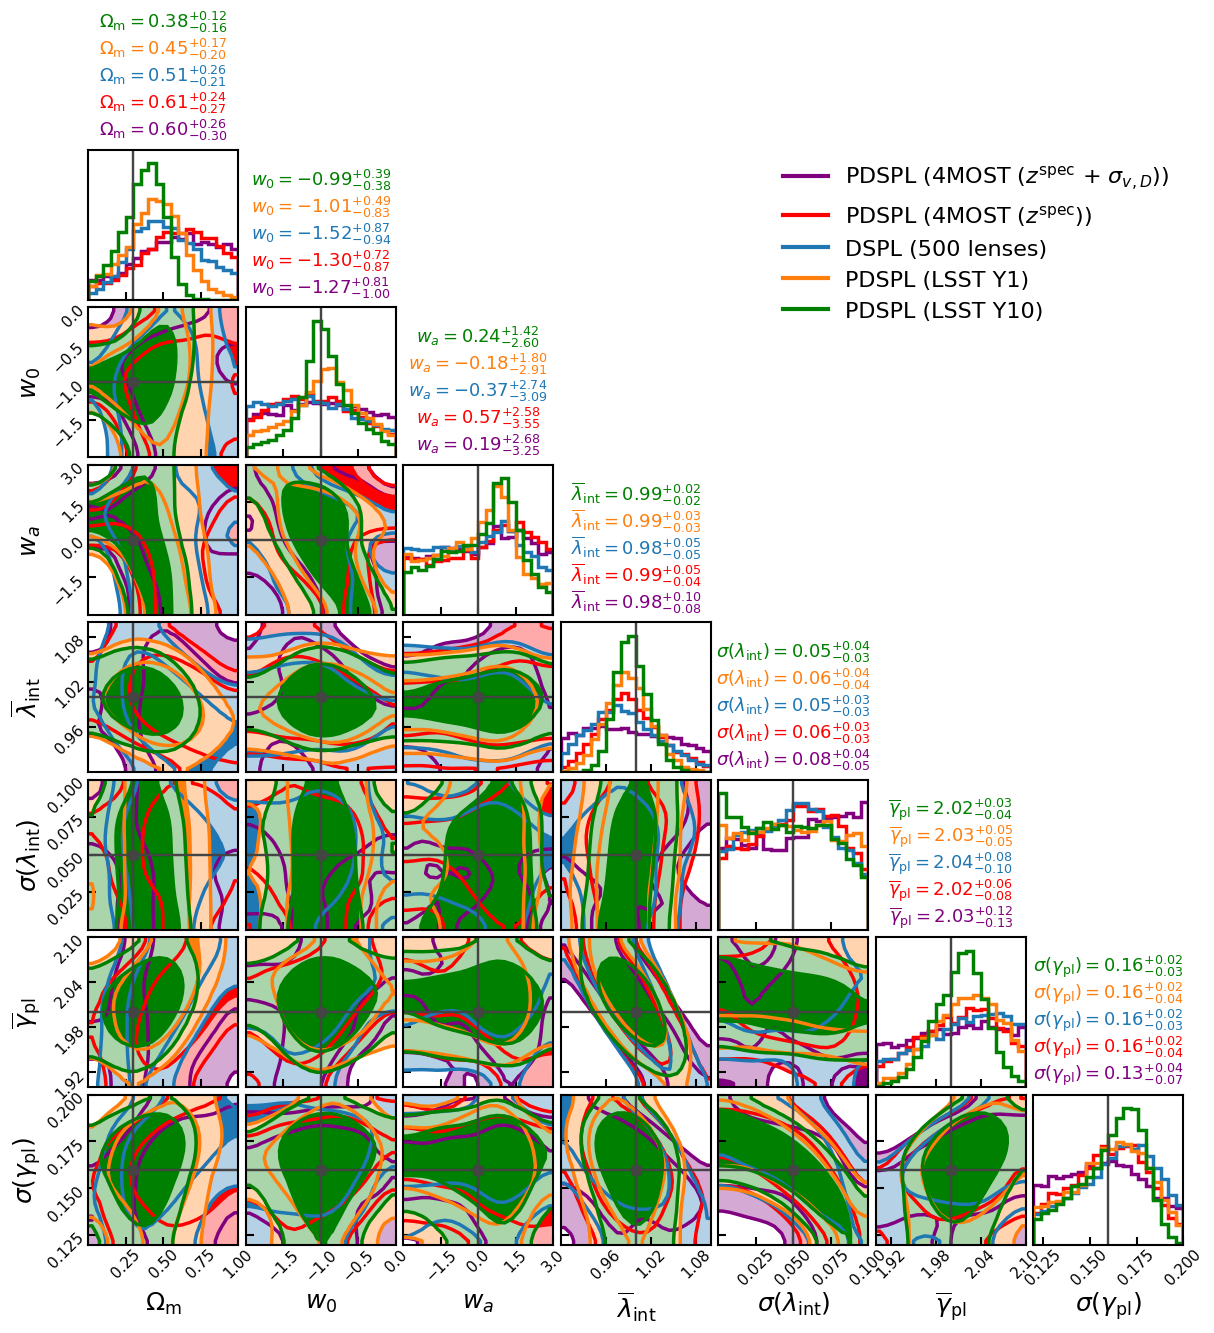

In [10]:
scenarios_to_plot = [
    'lsst_4most_spec-z_sigma_v', 
    'lsst_4most_spec-z', 
    'DSPL', 
    'lsst_y1', 
    'lsst_y10'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot, 
    custom_ranges=custom_ranges, 
    latex_labels=latex_labels, 
    figsize=(12, 12),
    show_multiple_titles=True,
)

plt.show()

###  b. DSPL, LSST Y1, and LSST Y10 Scatter Plot -- Uniform Priors

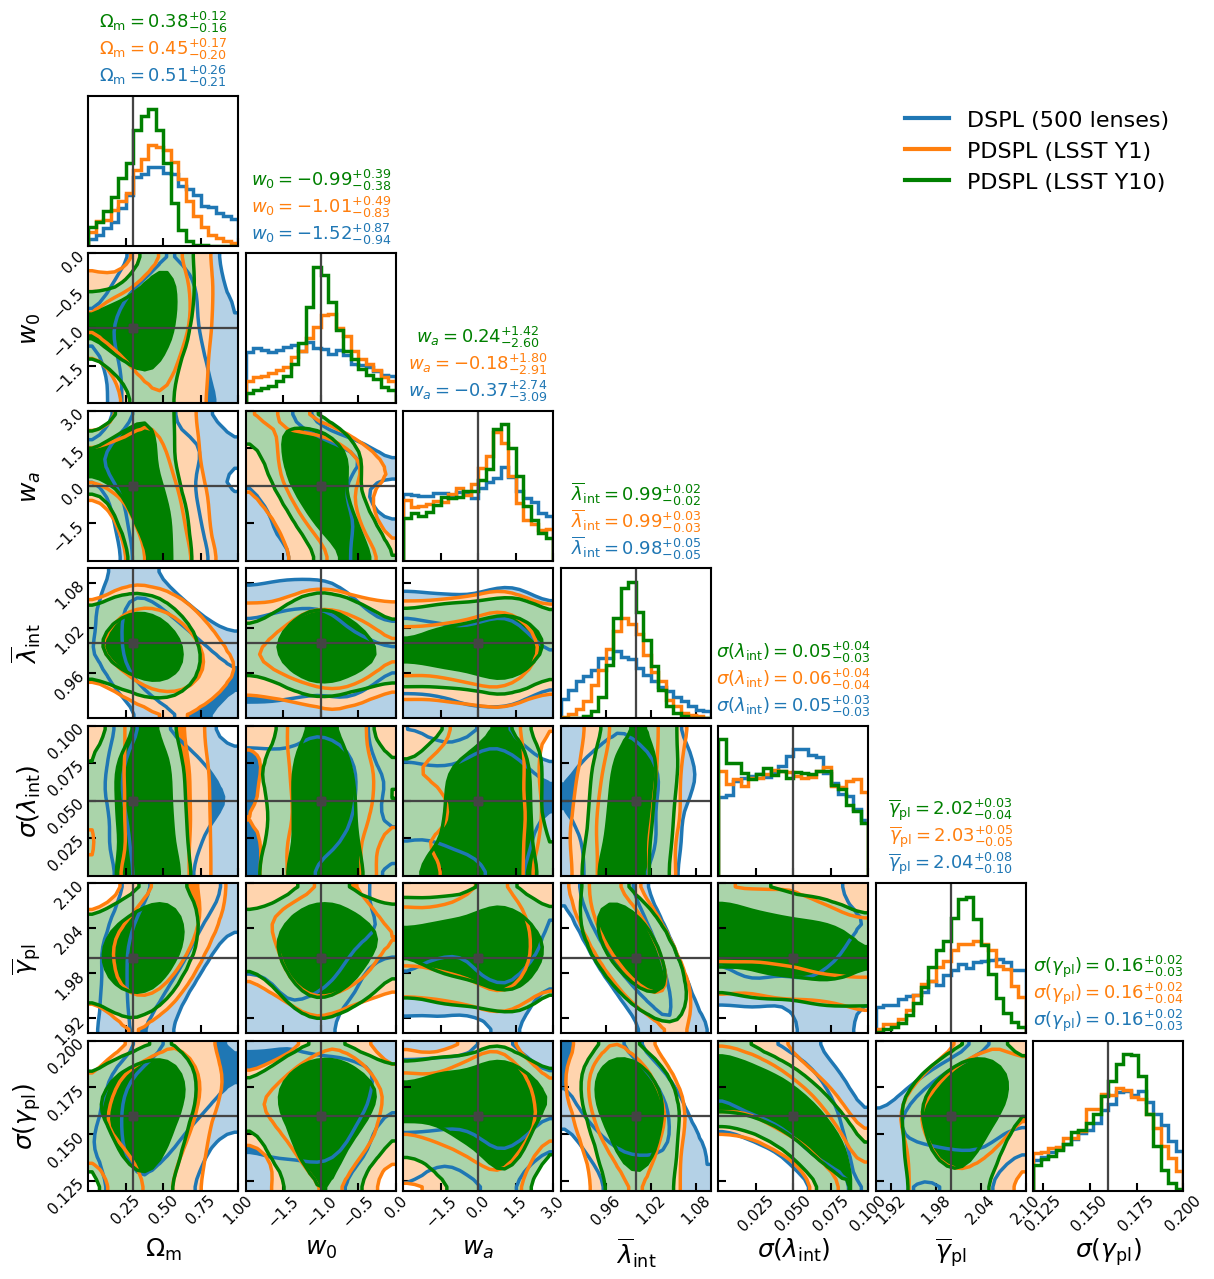

In [11]:
# Assuming 'scenarios', 'truth', and 'fixed_params' are already defined above

scenarios_to_plot = [
    'DSPL', 
    'lsst_y1', 
    'lsst_y10'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True,
)

plt.show()

###  c. All Scenarios Corner Plot -- $\Omega_m$ Prior

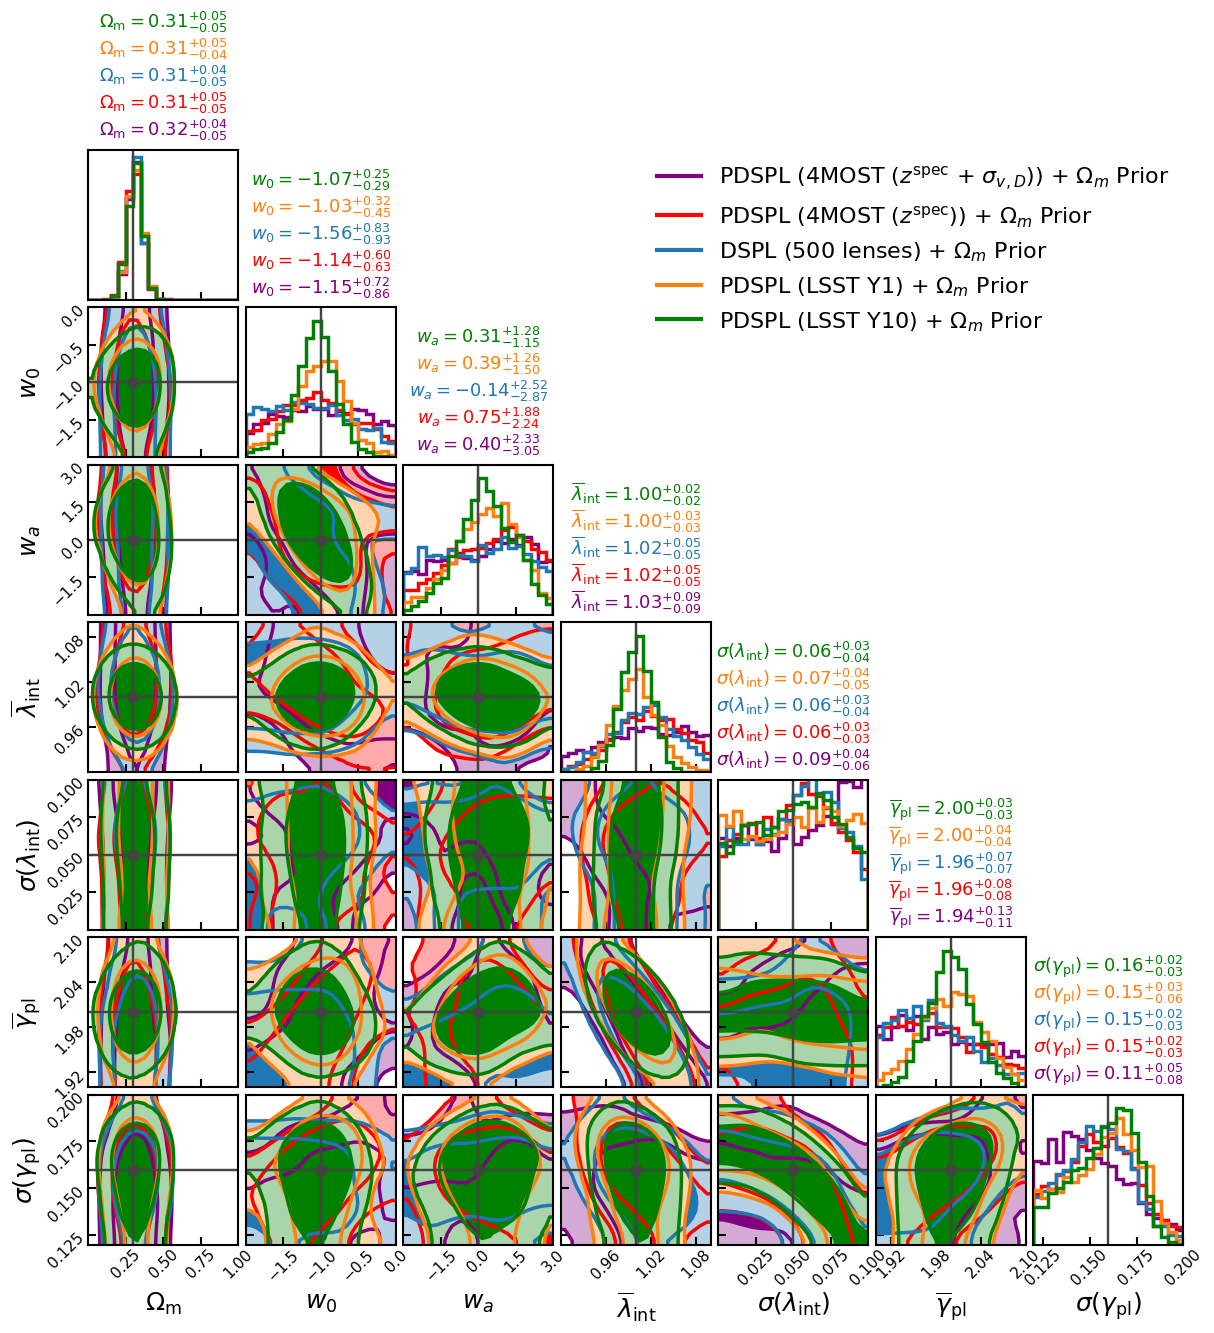

In [12]:
# Assuming 'scenarios', 'truth', and 'fixed_params' are already defined above

scenarios_to_plot = [
    'lsst_4most_spec-z_sigma_v_om_prior',
    'lsst_4most_spec-z_om_prior', 
    'DSPL_om_prior', 
    'lsst_y1_om_prior', 
    'lsst_y10_om_prior'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True
)

plt.show()

###  b. DSPL, LSST Y1, and LSST Y10 Corner Plot -- $\Omega_m$ Prior

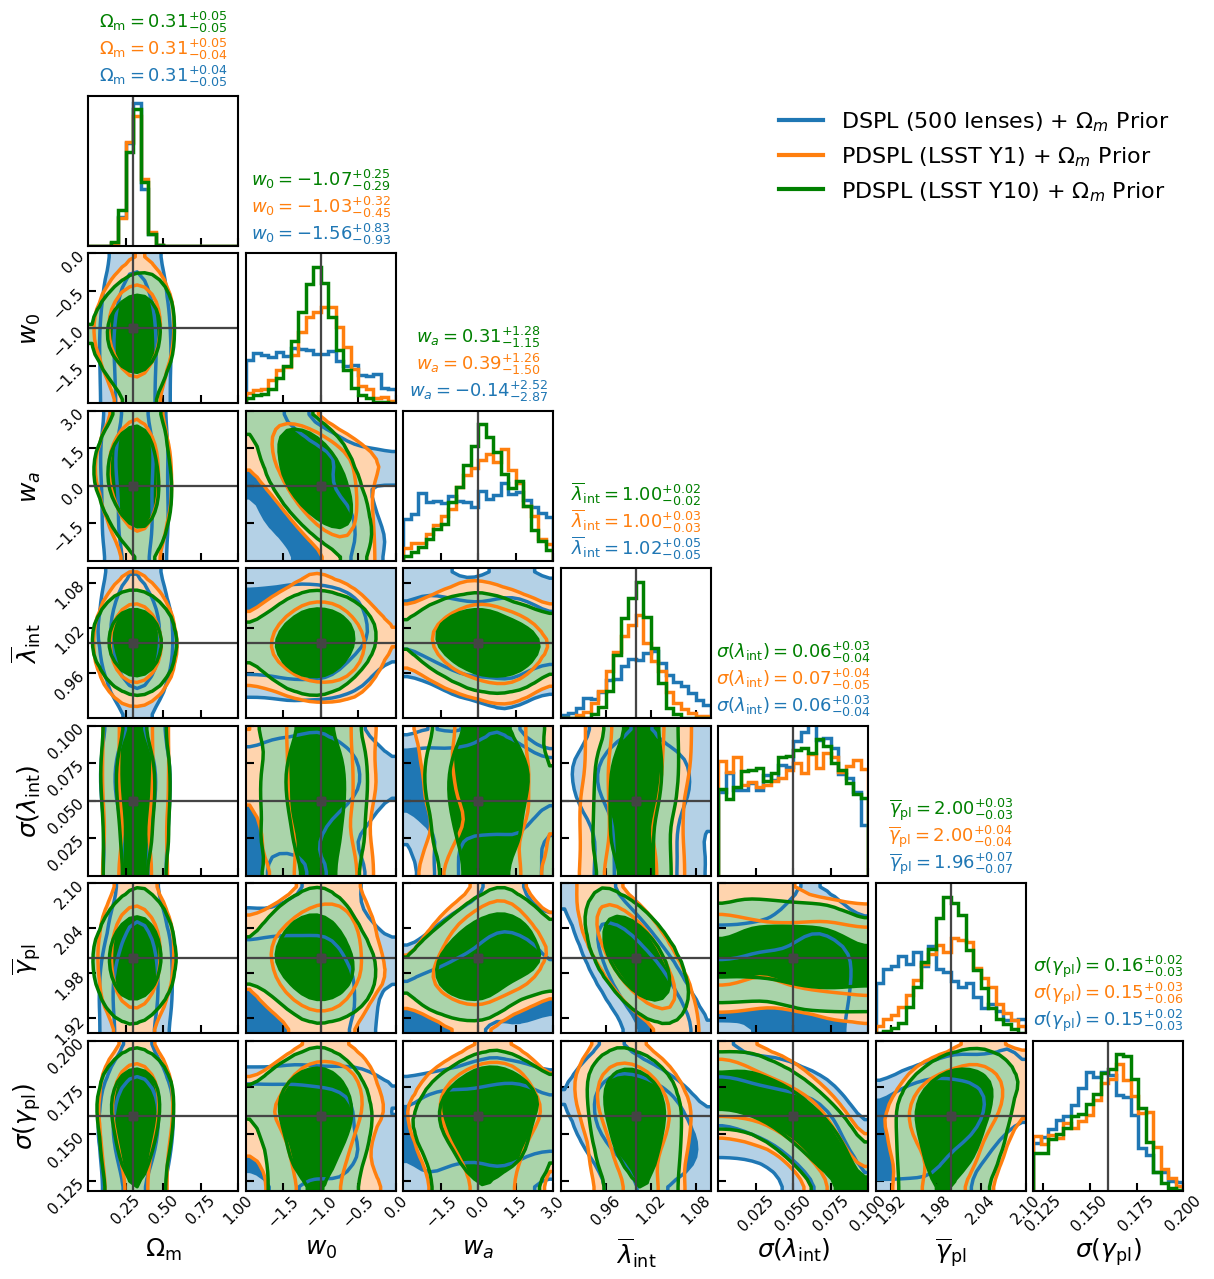

In [13]:
scenarios_to_plot = [
    'DSPL_om_prior', 
    'lsst_y1_om_prior', 
    'lsst_y10_om_prior'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True
)

plt.show()

###  c. LSST Y10 Corner Plot -- With and Without $\Omega_m$ Prior

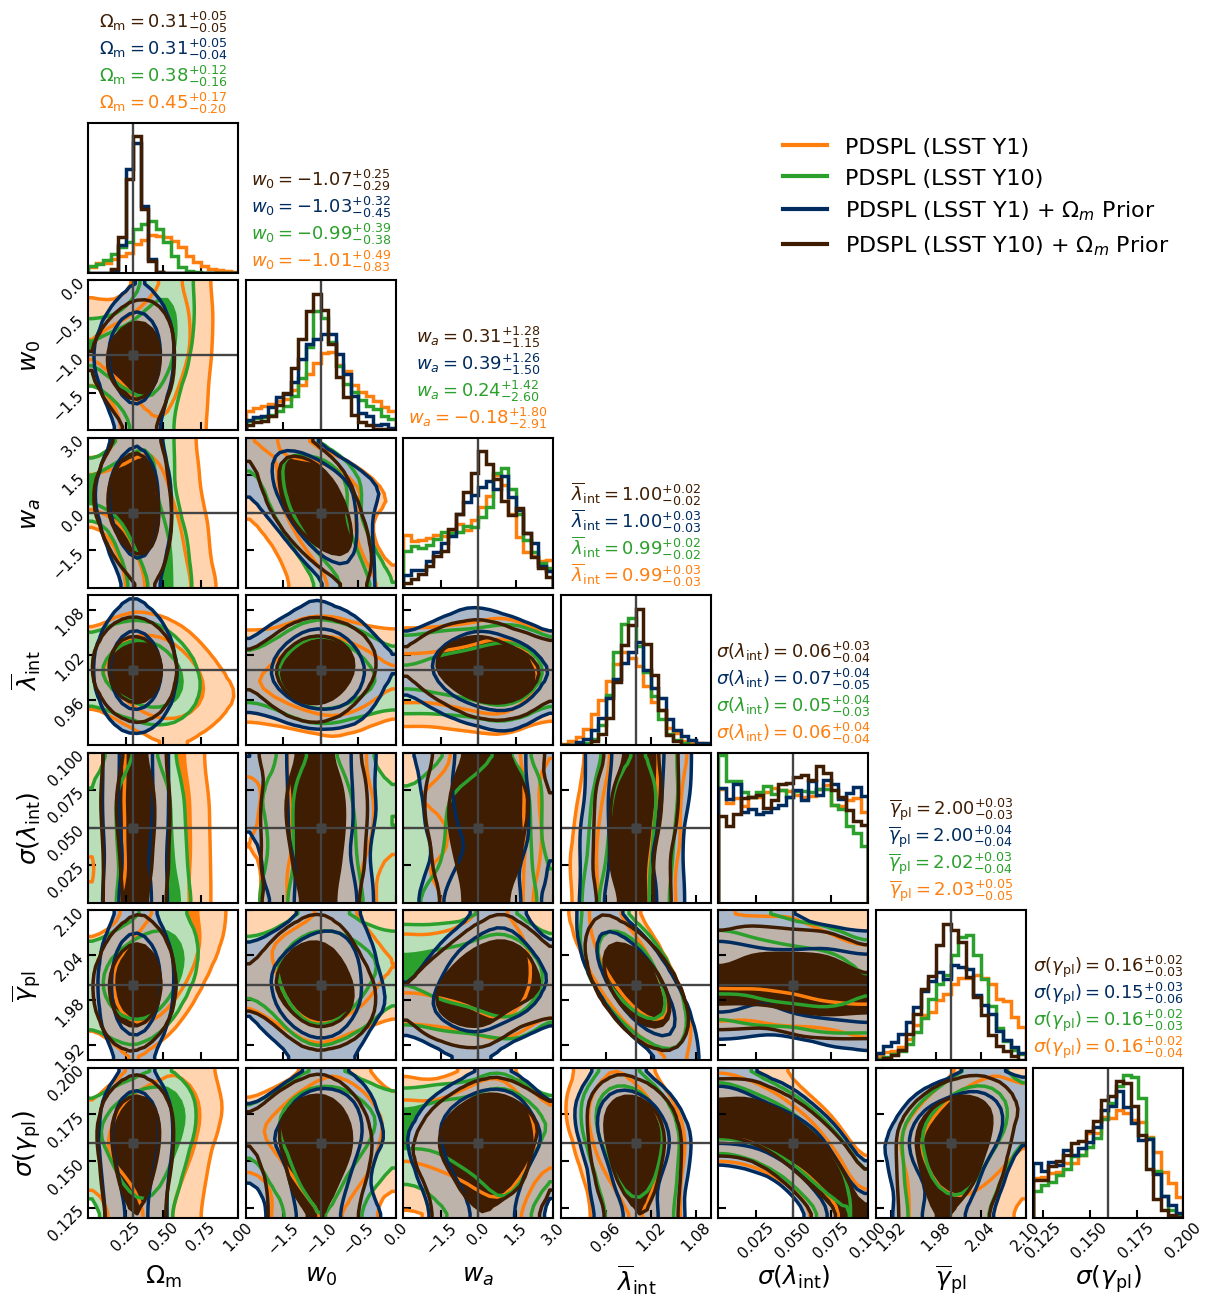

In [14]:
# Assuming 'scenarios', 'truth', and 'fixed_params' are already defined above

scenarios_to_plot = [
    # 'DSPL',
    'lsst_y1',
    'lsst_y10',
    # 'DSPL_om_prior', 
    'lsst_y1_om_prior', 
    'lsst_y10_om_prior'
]

custom_colors_dict = {
    # 'DSPL': '#1f77b4',
    'lsst_y1': '#ff7f0e',
    'lsst_y10': '#2ca02c',
    # 'DSPL_om_prior': '#1f77b4',
    'lsst_y1_om_prior': "#002B5F",
    'lsst_y10_om_prior': "#3e1d03"
}

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True,
    custom_colors_dict=custom_colors_dict
)

plt.show()

###  d. LSST Y10 vs DSPL Corner Plot -- With and Without $\Omega_m$ Prior

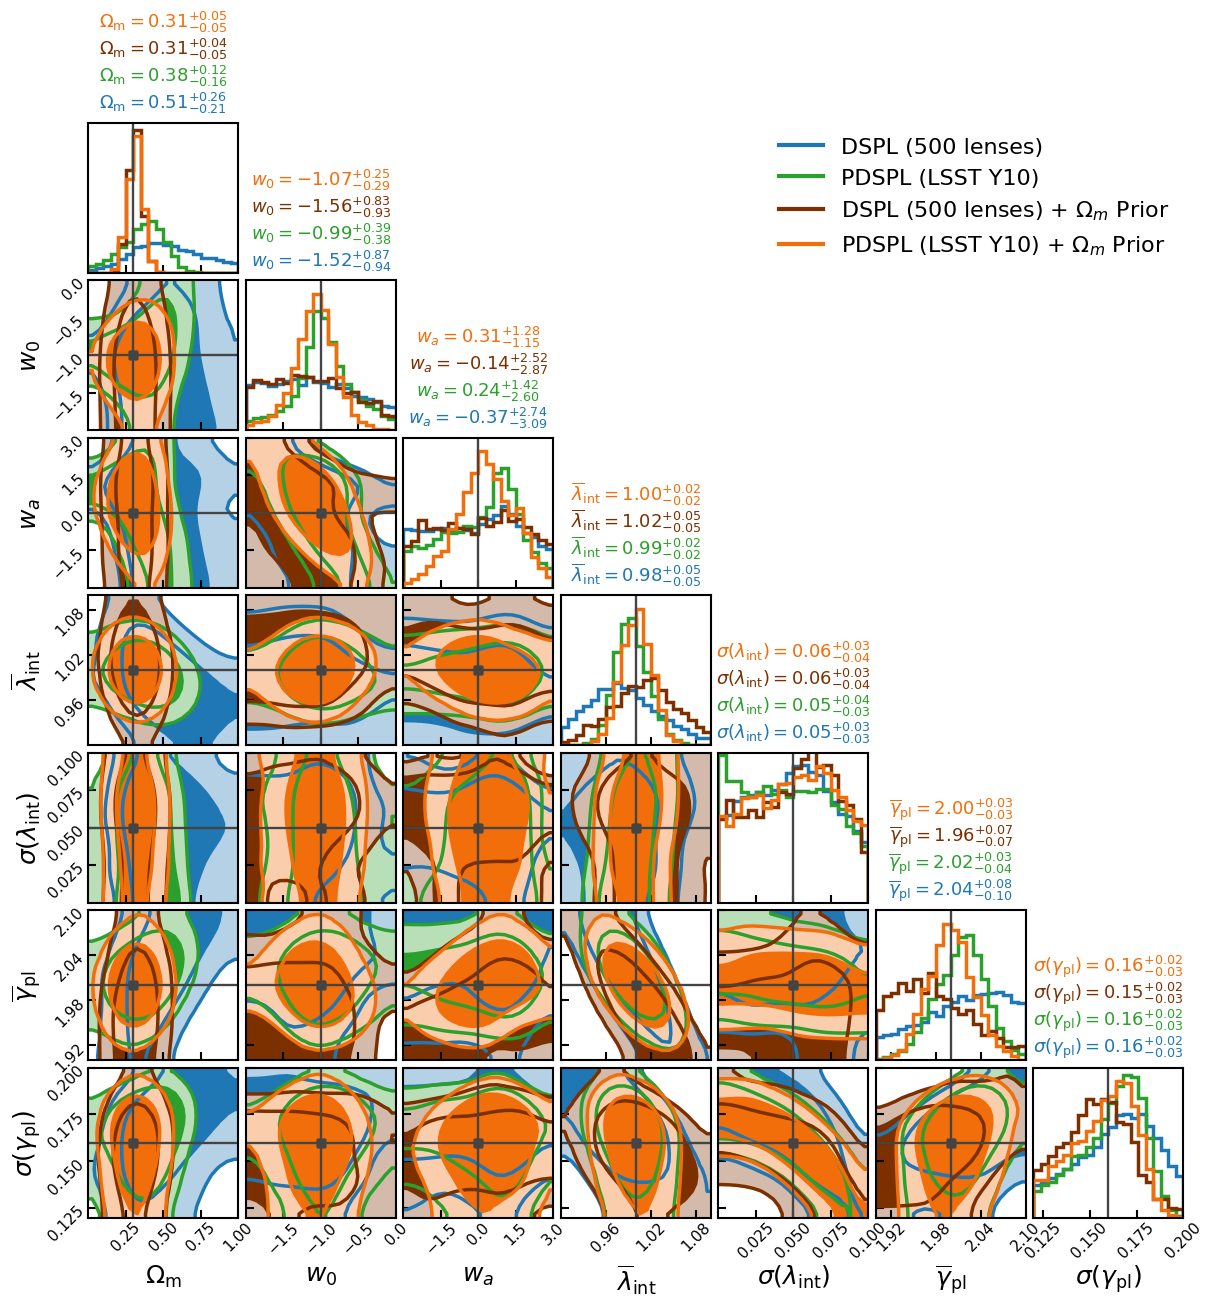

In [15]:
scenarios_to_plot = [
    'DSPL',
    # 'lsst_y1',
    'lsst_y10',
    'DSPL_om_prior', 
    # 'lsst_y1_om_prior', 
    'lsst_y10_om_prior'
]

custom_colors_dict = {
    'DSPL': '#1f77b4',
    # 'lsst_y1': '#ff7f0e',
    'lsst_y10': '#2ca02c',
    'DSPL_om_prior': "#7c3000",
    # 'lsst_y1_om_prior': '#ff7f0e',
    'lsst_y10_om_prior': "#f26e0a"
}

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True,
    custom_colors_dict=custom_colors_dict,
    save_path=FIGURE_DIRECTORY + "/pdspls_vs_DSPL_w0waCDM_scatter_forecast.pdf"
)

plt.show()

### e. All PDSPLs Corner Plot -- Uniform Priors

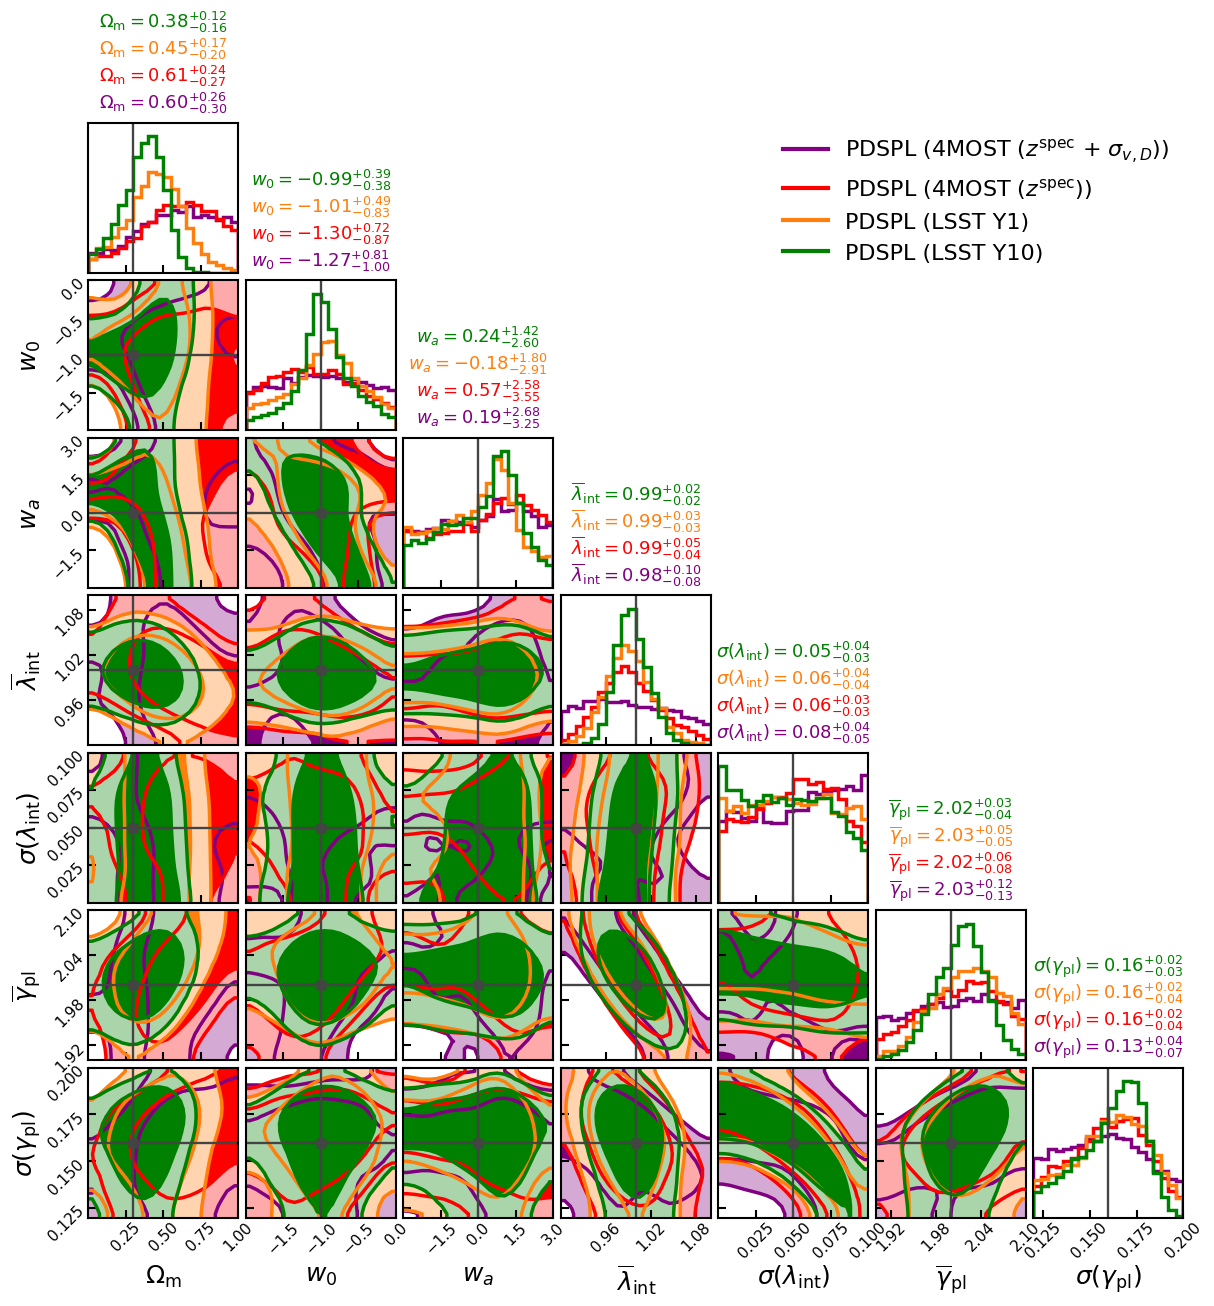

In [16]:
# Assuming 'scenarios', 'truth', and 'fixed_params' are already defined above

scenarios_to_plot = [
    'lsst_4most_spec-z_sigma_v',
    'lsst_4most_spec-z',
    'lsst_y1', 
    'lsst_y10'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True,
    save_path=FIGURE_DIRECTORY + "/pdspls_w0waCDM_scatter_forecast.pdf"
)

plt.show()

## Table of All Forecast Results

In [17]:
# print a latex table of the median and 16th/84th percentiles for each parameter and scenario
print("\n--- Parameter Summary Table (Median with 16th/84th Percentiles) ---")
print(f"{'Scenario':<80} | {'Parameter':<30} | {'Median':<10} | {'-1σ':<10} | {'+1σ':<10}")
print("-" * 150) 
for key in scenarios.keys():
    sc = scenarios[key]
    if 'samples' not in sc:
        continue
    
    samples = sc['samples']
    scenario_name = sc['name']
    
    for param_idx, param_key in enumerate(param_labels):
        samples_1d = samples[:, param_idx]
        q16, q50, q84 = np.percentile(samples_1d, [16, 50, 84])
        lower_err = q50 - q16
        upper_err = q84 - q50
        
        print(f"{scenario_name:<80} | {param_key:<30} | {q50:<10.3f} | {lower_err:<10.3f} | {upper_err:<10.3f}")


--- Parameter Summary Table (Median with 16th/84th Percentiles) ---
Scenario                                                                         | Parameter                      | Median     | -1σ        | +1σ       
------------------------------------------------------------------------------------------------------------------------------------------------------
PDSPL (LSST Y1)                                                                  | $\Omega_m$                     | 0.451      | 0.197      | 0.175     
PDSPL (LSST Y1)                                                                  | $w_0$                          | -1.008     | 0.828      | 0.491     
PDSPL (LSST Y1)                                                                  | $w_a$                          | -0.180     | 2.914      | 1.801     
PDSPL (LSST Y1)                                                                  | $\bar{\lambda}_{int}$          | 0.990      | 0.029      | 0.031     
PDSPL (LSST Y1)

In [18]:
# save the scenarios dictionary with the samples included into a new pickle file for later use
with open('../data/samples/forecast_scenarios_w0waCDM_scatter_custom.pkl', 'wb') as f:
    pickle.dump(scenarios, f) 

## Experiment 1 - Effect of Photometric Redshift Uncertainties on Forecasts

Here we just pick LSST Y10 as the scenario to test the effect of photometric redshift uncertainties on the forecasts. We will use the same settings as before.

In [ ]:
# --- 1. CONFIGURATION & TRUTH ---
truth = {
    'h0': 70.0, 'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16
}
fixed_params = {'h0': 70.0}
cosmo_true = Flatw0waCDM(H0=truth['h0'], Om0=truth['om'], w0=truth['w0'], wa=truth['wa'])

# --- 2. INITIALIZE SCENARIOS ---
scenarios_lsst_y10_z_err = {}

# Populate PDSPL scenarios from pickle
for rel_z_error in [0.00, 0.01, 0.02, 0.03, 0.05]:
    key = 'lsst_y10'
    key_long = key + f"_z_error_{rel_z_error:.2f}"
    scenarios_lsst_y10_z_err[key_long] = {
        'name': f"PDSPL ({pdspl_samples[key]['name']})" + f" $\\sigma_z = {rel_z_error:.2f}(1 + z)$",
        'down_sampling': len(pdspl_samples[key]['pairs_analysis']['pairs_table']) / 200, # downsample to at most 200 lenses for computational feasibility
        'num_lenses': len(pdspl_samples[key]['pairs_analysis']['pairs_table']),
        'color': pdspl_samples[key]['color'],
        'coeffs': pdspl_samples[key]['pairs_analysis']['scatter_vs_dissimilarity_fit_coeffs'],
        'pairs_table': pdspl_samples[key]['pairs_analysis']['pairs_table'],
        'pairs_table_with_errors': pdspl_samples[key]['pairs_analysis']['pairs_table_with_errors'],
        'sigma_beta': pdspl_samples[key]['pairs_analysis']['scatter_in_beta_E'],
        'redshift_error_rel': rel_z_error,
        'backend_path': None
    }

# --- 3. GENERATE MOCK DATASETS ---
print(f"{'SCENARIO':<60} | {'N_LENS':<10} | {'STATUS'}")
print("-" * 85)

for key in scenarios_lsst_y10_z_err.keys():
    sc = scenarios_lsst_y10_z_err[key]
    num_samples = int(sc['num_lenses'] / sc['down_sampling'])
    kwargs_list = []

    # Generation from PDSPL tables
    pairs_table = sc['pairs_table']
    pairs_table_with_errors = sc['pairs_table_with_errors']
    coeffs = sc['coeffs']
    random_indices = np.random.choice(len(pairs_table), size=num_samples, replace=False)
    
    for i in random_indices:
        z_lens = pairs_table["z_D"][i]
        z1 = pairs_table["z_S1"][i]
        z2 = pairs_table["z_S2"][i]
        
        dissimilarity = pairs_table_with_errors['dissimilarity'][i]
        rel_scatter_in_beta_E = np.polyval(coeffs, dissimilarity)
        
        sigma_beta_meas, sigma_beta_los = 0.01, 0.01
        rel_scatter_in_beta_E = np.sqrt(rel_scatter_in_beta_E**2 + sigma_beta_meas**2 + sigma_beta_los**2)
        
        kwargs_list.append(draw_lens_from_given_zs(
            z_lens=z_lens, z1=z1, z2=z2,
            lambda_mst_mean=truth['lambda_int'], lambda_mst_sigma=truth['lambda_sigma'],
            gamma_pl_mean=truth['gamma_pl'], gamma_pl_sigma=truth['gamma_sigma'],
            sigma_beta_rel=rel_scatter_in_beta_E, 
            down_sampling=sc['down_sampling'], 
            with_noise=False, # For ASIMOV inference
            cosmo=cosmo_true, 
            redshift_error_rel=sc['redshift_error_rel']
        ))
            
    # Save the generated dataset into the scenario dictionary
    sc['kwargs_list'] = kwargs_list
    print(f"{sc['name']:<60} | {num_samples:<10} | GENERATED")

SCENARIO                                                     | N_LENS     | STATUS
-------------------------------------------------------------------------------------
PDSPL (LSST Y10) $\sigma_z = 0.00$                           | 200        | GENERATED
PDSPL (LSST Y10) $\sigma_z = 0.01$                           | 200        | GENERATED
PDSPL (LSST Y10) $\sigma_z = 0.02$                           | 200        | GENERATED
PDSPL (LSST Y10) $\sigma_z = 0.03$                           | 200        | GENERATED
PDSPL (LSST Y10) $\sigma_z = 0.05$                           | 200        | GENERATED


In [28]:
# --- 1. INFERENCE SETTINGS ---
my_guess = {
    'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16
}

my_spreads = {
    'om': 0.1, 'w0': 0.1, 'wa': 0.1,
    'lambda_int': 0.1, 'lambda_sigma': 0.01,
    'gamma_pl': 0.1, 'gamma_sigma': 0.01
}

my_priors = {
    'h0': ('uniform', 50.0, 90.0),
    'om': ('uniform', 0.0, 1.0),
    'w0': ('uniform', -3.0, 0.0),
    'wa': ('uniform', -5.0, 5.0),
    'lambda_int': ('uniform', 0.8, 1.2),
    'lambda_sigma': ('uniform', 0.0, 0.2),
    'gamma_pl': ('uniform', 1.0, 3.0),
    'gamma_sigma': ('uniform', 0.0, 0.5)
}

# --- 2. EXECUTION LOOP ---
print("\n--- Starting MCMC Samplers ---")

param_labels = None 

for key in scenarios_lsst_y10_z_err.keys():
    sc = scenarios_lsst_y10_z_err[key]
    
    if 'kwargs_list' not in sc:
        continue # Skip if data wasn't generated
        
    print(f"\nRunning Inference for: {sc['name']}")
    
    samples, labels = run_dspl_inference(
        sc['kwargs_list'],
        n_walkers=64,
        n_steps=2000, 
        n_burn=500,
        initial_guess=my_guess,
        fixed_params=fixed_params,
        initial_scatter=my_spreads,
        priors=my_priors,
        down_sampling=sc['down_sampling'],
        backend_path=sc['backend_path']
    )
    
    sc['samples'] = samples
    param_labels = labels # Saves labels for plotting step
    print(f"{sc['name']} | INFERENCE COMPLETE")


--- Starting MCMC Samplers ---

Running Inference for: PDSPL (LSST Y10) $\sigma_z = 0.00$
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 429.68


100%|██████████| 2000/2000 [06:53<00:00,  4.84it/s]


PDSPL (LSST Y10) $\sigma_z = 0.00$ | INFERENCE COMPLETE

Running Inference for: PDSPL (LSST Y10) $\sigma_z = 0.01$
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 429.68


100%|██████████| 2000/2000 [06:30<00:00,  5.13it/s]


PDSPL (LSST Y10) $\sigma_z = 0.01$ | INFERENCE COMPLETE

Running Inference for: PDSPL (LSST Y10) $\sigma_z = 0.02$
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 429.68


...

PDSPL (LSST Y10) $\sigma_z = 0.02$ | INFERENCE COMPLETE

Running Inference for: PDSPL (LSST Y10) $\sigma_z = 0.03$
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 429.68


100%|██████████| 2000/2000 [06:30<00:00,  5.12it/s]


PDSPL (LSST Y10) $\sigma_z = 0.03$ | INFERENCE COMPLETE

Running Inference for: PDSPL (LSST Y10) $\sigma_z = 0.05$
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 429.68


100%|██████████| 2000/2000 [06:20<00:00,  5.25it/s]

PDSPL (LSST Y10) $\sigma_z = 0.05$ | INFERENCE COMPLETE


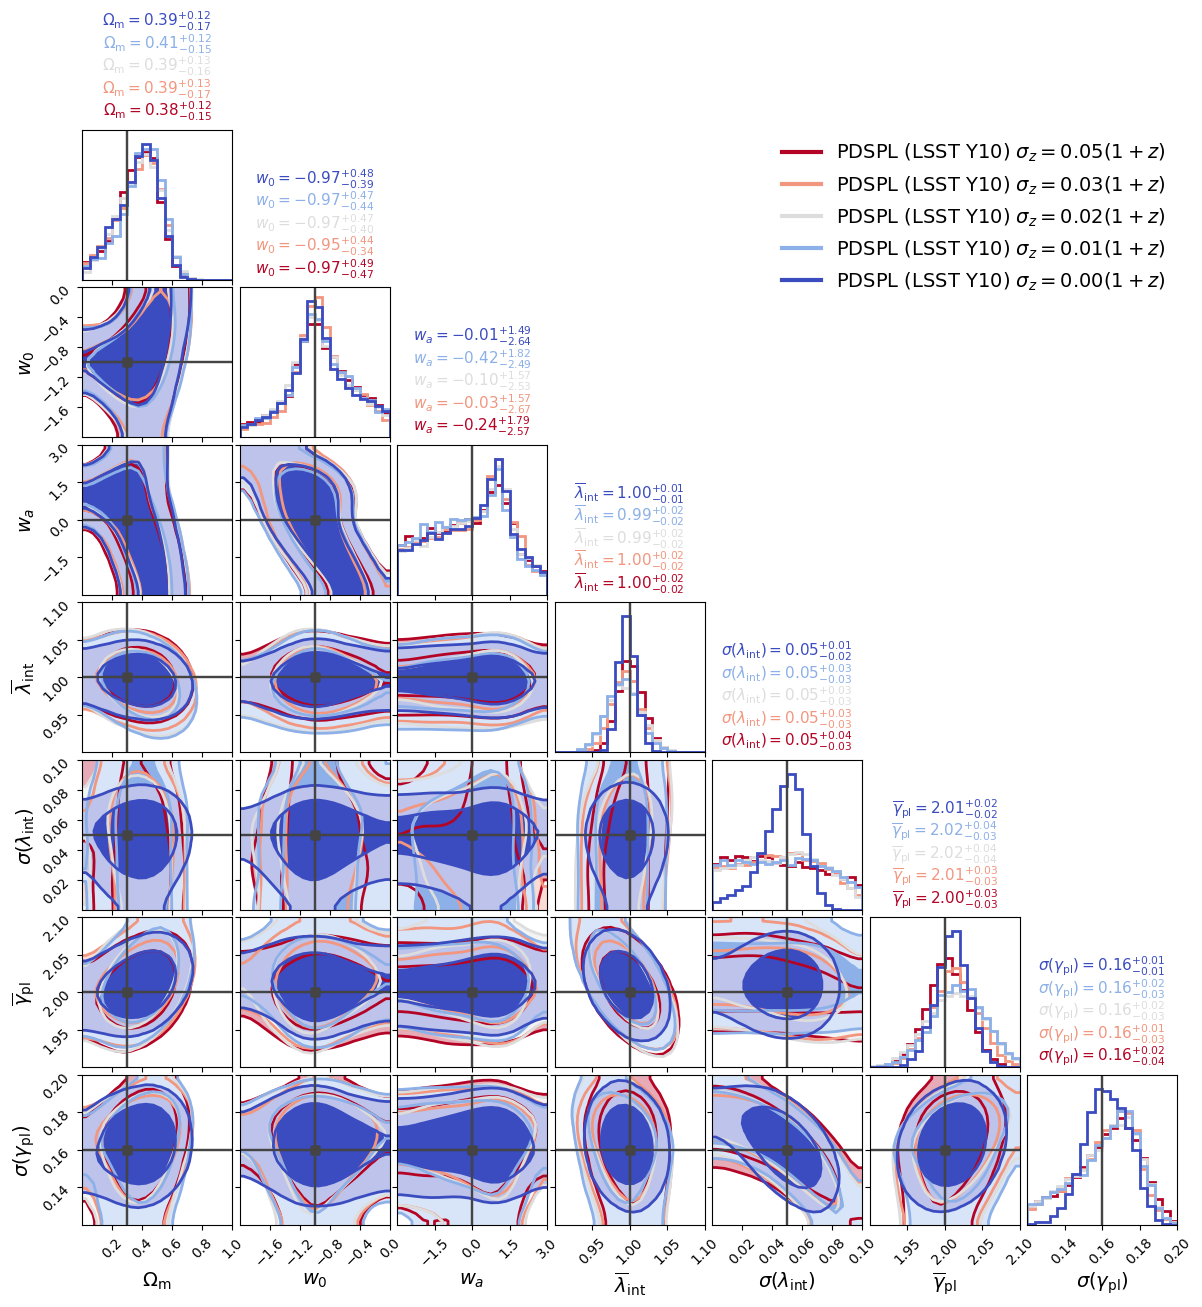

In [35]:
# latex_labels = {
#     'om': r"$\Omega_{\rm m}$", 'w0': r"$w_0$", 'wa': r"$w_a$", 
#     'lambda_int': r"$\overline{\lambda}_{\rm int}$", 
#     'gamma_pl': r"$\overline{\gamma}_{\rm pl}$", 
#     'gamma_sigma': r"$\sigma({\gamma}_{\rm pl})$", 
#     'lambda_sigma': r"$\sigma({\lambda}_{\rm int})$"
# }

# custom_ranges = [
#     (0, 1),           # om
#     (-2, 0),          # w0
#     (-3, 3),          # wa
#     (truth['lambda_int'] - 0.1, truth['lambda_int'] + 0.1), # lambda_int
#     (0.0, 0.10),      # lambda_sigma
#     (truth['gamma_pl'] - 0.1, truth['gamma_pl'] + 0.1), # gamma_pl
#     (0.12, 0.20),     # gamma_sigma
# ]

scenarios_to_plot = [
    'lsst_y10_z_error_0.05',
    'lsst_y10_z_error_0.03',
    'lsst_y10_z_error_0.02',
    'lsst_y10_z_error_0.01',
    'lsst_y10_z_error_0.00',
]

custom_colors_dict = {
    'lsst_y10_z_error_0.00': '#3b4cc0',
    'lsst_y10_z_error_0.01': '#8cb0e7',
    'lsst_y10_z_error_0.02': '#dddddd',
    'lsst_y10_z_error_0.03': '#f2967f',
    'lsst_y10_z_error_0.05': '#b40426',
}

fig = plot_dspl_corner(
    scenarios=scenarios_lsst_y10_z_err, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True,
    custom_colors_dict=custom_colors_dict
)

plt.show()